#  AI-Based Disaster Survivor Detection System

**Architecture:** YOLOv8 Nano (CPU-Optimised, ~3.2M parameters)  
**Framework:** Ultralytics YOLOv8 | Transfer Learning from COCO  
**Target:** Real-time survivor detection in UAV aerial imagery  

GROUP MEMBERS :   **RIDA IMTIAZ (230201035)**
                 **FATIMA SHAHEEN (230201076)**                  



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!nvidia-smi

Tue May 26 07:14:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             49W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [4]:
!pip install --upgrade --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 148.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 119.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 113.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 62.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 143.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 21.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 48.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 21.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/1

In [5]:
import torch
print("Is CUDA available?:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Active GPU Name:", torch.cuda.get_device_name(0))

Is CUDA available?: True
Active GPU Name: NVIDIA A100-SXM4-40GB


## Cell 1 — Install Dependencies

In [9]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

packages = [
    "ultralytics",        # YOLOv8 framework
    "opencv-python",      # Image processing
    "albumentations",     # Augmentation library
    "matplotlib",         # Plotting
    "seaborn",            # Confusion matrix heatmap
    "PyYAML",             # YAML config generation
    "tqdm",               # Progress bars
    "Pillow",             # Image I/O
]

print("Installing dependencies...")
for pkg in packages:
    install(pkg)
print(" All dependencies installed.")

Installing dependencies...
 All dependencies installed.


## Cell 2 — Configuration: Set Your Paths Here

In [10]:
from pathlib import Path
import os, yaml

DATASET_ROOT = Path("/content/drive/MyDrive/archive (5)/C2A_Dataset/new_dataset3")

TRAIN_IMAGES  = DATASET_ROOT / "train" / "images"
TRAIN_LABELS  = DATASET_ROOT / "train" / "labels"
VAL_IMAGES    = DATASET_ROOT / "val"   / "images"
VAL_LABELS    = DATASET_ROOT / "val"   / "labels"
TEST_IMAGES   = DATASET_ROOT / "test"  / "images"
TEST_LABELS   = DATASET_ROOT / "test"  / "labels"

OUTPUT_DIR    = Path("./sar_output")
OUTPUT_DIR.mkdir(exist_ok=True)

for p in [TRAIN_IMAGES, TRAIN_LABELS, VAL_IMAGES, VAL_LABELS, TEST_IMAGES, TEST_LABELS]:
    status = "" if p.exists() else " MISSING"
    print(f"  {status}  {p}")

    /content/drive/MyDrive/archive (5)/C2A_Dataset/new_dataset3/train/images
    /content/drive/MyDrive/archive (5)/C2A_Dataset/new_dataset3/train/labels
    /content/drive/MyDrive/archive (5)/C2A_Dataset/new_dataset3/val/images
    /content/drive/MyDrive/archive (5)/C2A_Dataset/new_dataset3/val/labels
    /content/drive/MyDrive/archive (5)/C2A_Dataset/new_dataset3/test/images
    /content/drive/MyDrive/archive (5)/C2A_Dataset/new_dataset3/test/labels


## Cell 3 — Dataset Integrity Checker

In [11]:
def check_dataset_integrity(images_dir: Path, labels_dir: Path, split_name: str):
    """
    Verifies image-label pairing integrity for a dataset split.
    Reports:
      - Images missing a corresponding label file
      - Label files with no matching image
      - Empty label files (unannotated frames)
    """
    IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

    images = {f.stem: f for f in images_dir.iterdir() if f.suffix.lower() in IMAGE_EXTS}
    labels = {f.stem: f for f in labels_dir.iterdir() if f.suffix == ".txt"}

    missing_labels  = [stem for stem in images if stem not in labels]
    missing_images  = [stem for stem in labels if stem not in images]
    empty_labels    = [stem for stem, lf in labels.items() if lf.stat().st_size == 0]

    print(f"\n{'='*55}")
    print(f"  Dataset Integrity Report — {split_name.upper()} split")
    print(f"{'='*55}")
    print(f"  Total images : {len(images)}")
    print(f"  Total labels : {len(labels)}")
    print(f"  Missing labels (unannotated images): {len(missing_labels)}")
    print(f"  Missing images (orphan labels)      : {len(missing_images)}")
    print(f"  Empty label files (no annotations)  : {len(empty_labels)}")

    if missing_labels:
        print(f"\n  ⚠ Images without labels (first 5):")
        for s in missing_labels[:5]:
            print(f"     {s}")

    if empty_labels:
        print(f"\n  ⚠ Empty label files (first 5):")
        for s in empty_labels[:5]:
            print(f"     {s}")

    ok = (len(missing_labels) == 0 and len(empty_labels) == 0)
    print(f"\n  {' Split is CLEAN.' if ok else '⚠  Issues detected — review above.'}")
    return {"images": len(images), "labels": len(labels),
            "missing_labels": missing_labels, "empty_labels": empty_labels}

# Run integrity checks on all splits
stats_train = check_dataset_integrity(TRAIN_IMAGES, TRAIN_LABELS, "train")
stats_val   = check_dataset_integrity(VAL_IMAGES,   VAL_LABELS,   "valid")
stats_test  = check_dataset_integrity(TEST_IMAGES,  TEST_LABELS,  "test")


  Dataset Integrity Report — TRAIN split
  Total images : 6129
  Total labels : 6129
  Missing labels (unannotated images): 0
  Missing images (orphan labels)      : 0
  Empty label files (no annotations)  : 0

   Split is CLEAN.

  Dataset Integrity Report — VALID split
  Total images : 2043
  Total labels : 2043
  Missing labels (unannotated images): 0
  Missing images (orphan labels)      : 0
  Empty label files (no annotations)  : 0

   Split is CLEAN.

  Dataset Integrity Report — TEST split
  Total images : 2043
  Total labels : 2043
  Missing labels (unannotated images): 0
  Missing images (orphan labels)      : 0
  Empty label files (no annotations)  : 0

   Split is CLEAN.


## Cell 4 — Auto-Detect Class Names from Label Files

In [12]:
def extract_class_ids(labels_dir: Path) -> set:
    """Scans all YOLO .txt label files and returns unique class IDs found."""
    ids = set()
    for lf in labels_dir.glob("*.txt"):
        for line in lf.read_text().strip().splitlines():
            parts = line.strip().split()
            if parts:
                ids.add(int(parts[0]))
    return ids

all_ids = (extract_class_ids(TRAIN_LABELS) |
           extract_class_ids(VAL_LABELS)   |
           extract_class_ids(TEST_LABELS))

NUM_CLASSES = max(all_ids) + 1   # total class slots needed

print(f"\n Detected class IDs: {sorted(all_ids)}")
print(f"   → Setting nc = {NUM_CLASSES}")


CLASS_NAME_MAP = {
    0: "survivor",
    1: "body",
    2: "person",
}
# Build names list ordered by class ID
CLASS_NAMES = [CLASS_NAME_MAP.get(i, f"class_{i}") for i in range(NUM_CLASSES)]
print(f"   → Class names: {CLASS_NAMES}")


 Detected class IDs: [0]
   → Setting nc = 1
   → Class names: ['survivor']


In [7]:
import torch

if torch.cuda.is_available():
    print(f"GPU Available: {torch.cuda.is_available()}")
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")
else:
    print("GPU is NOT available in this runtime.")

GPU Available: True
GPU Device Name: NVIDIA A100-SXM4-40GB


## Cell 5 — Generate data.yaml (YOLO configuration file)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ data.yaml written to: /content/sar_output/data.yaml

── data.yaml contents ──────────────────────────
train: /content/drive/MyDrive/archive (5)/C2A_Dataset/new_dataset3/train/images
val: /content/drive/MyDrive/archive (5)/C2A_Dataset/new_dataset3/val/images
test: /content/drive/MyDrive/archive (5)/C2A_Dataset/new_dataset3/test/images
nc: 1
names:
- survivor



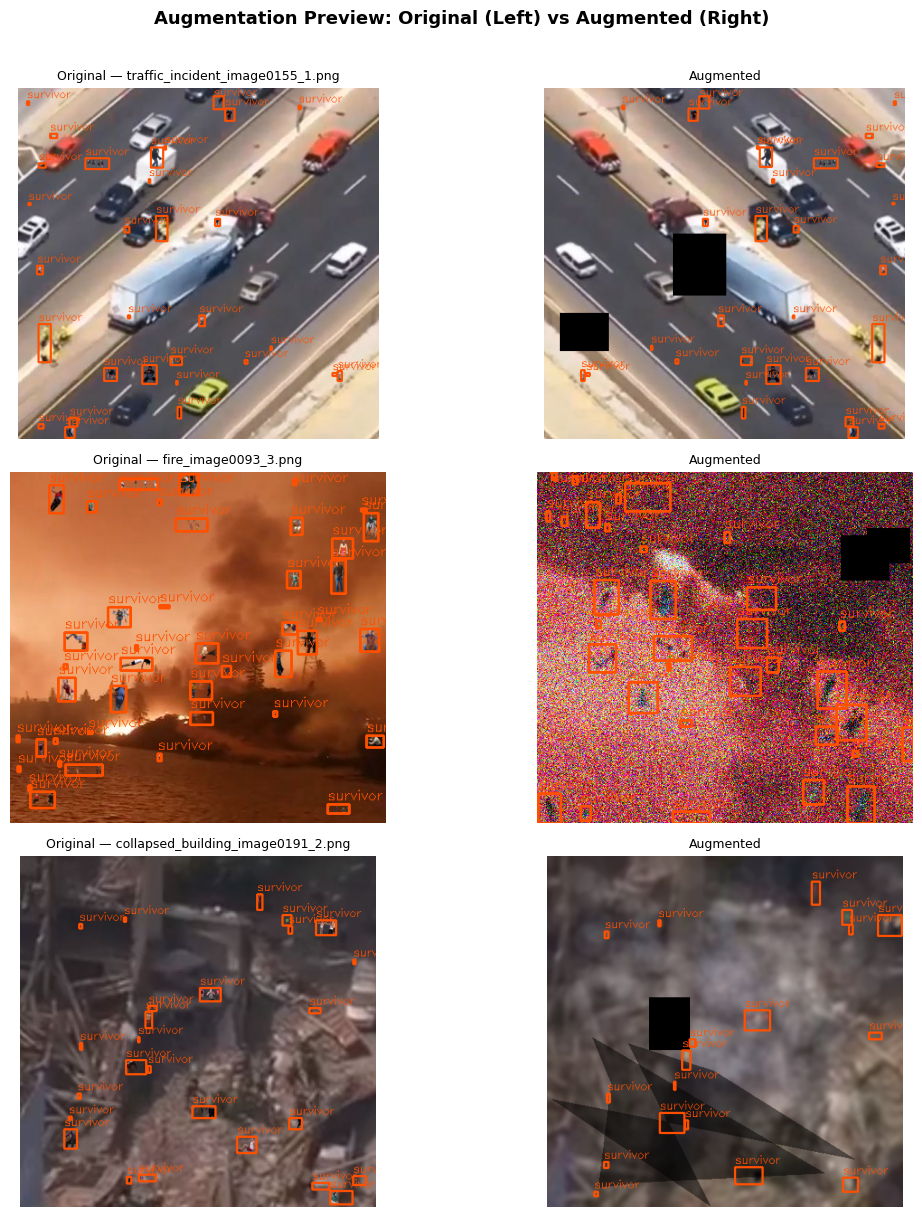

✅ Augmentation preview saved → sar_output/augmentation_preview.png
✅ Loaded yolov8m.pt
   Parameters : ~25,902,640
   Architecture: DetectionModel
Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=sar_output/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, mo

In [8]:
import cv2
import yaml
import random
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from pathlib import Path
from ultralytics import YOLO

# ══════════════════════════════════════════════════════════════════════
# CELL 5 — YAML Configuration Write
# ══════════════════════════════════════════════════════════════════════
DATA_YAML_PATH = OUTPUT_DIR / "data.yaml"

data_yaml_content = {
    # Absolute paths ensure YOLO finds data regardless of working directory
    "train": str(TRAIN_IMAGES.resolve()),
    "val":   str(VAL_IMAGES.resolve()),
    "test":  str(TEST_IMAGES.resolve()),
    "nc":    NUM_CLASSES,
    "names": CLASS_NAMES,
}

with open(DATA_YAML_PATH, "w") as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False, sort_keys=False)

print(f" data.yaml written to: {DATA_YAML_PATH.resolve()}")
print("\n── data.yaml contents ──────────────────────────")
print(DATA_YAML_PATH.read_text())


# ══════════════════════════════════════════════════════════════════════
# CELL 6 — Augmentation Preview (Albumentations)
#          Shows what augmented images look like before training
# ══════════════════════════════════════════════════════════════════════
def get_augmentation_pipeline():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.Rotate(limit=15, border_mode=cv2.BORDER_REFLECT_101, p=0.4),
        A.Perspective(scale=(0.02, 0.06), p=0.3),
        A.RandomBrightnessContrast(
            brightness_limit=0.35,
            contrast_limit=0.35,
            p=0.6
        ),
        A.GaussianBlur(blur_limit=(3, 7), p=0.4),
        A.MotionBlur(blur_limit=7, p=0.3),
        A.GaussNoise(p=0.3),
        A.RandomFog(p=0.2),
        A.RandomShadow(p=0.2),
        A.CoarseDropout(p=0.3),
        A.HueSaturationValue(
            hue_shift_limit=15,
            sat_shift_limit=25,
            val_shift_limit=20,
            p=0.4
        ),
    ], bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels'],
        min_visibility=0.3
    ))


def preview_augmentations(images_dir: Path, labels_dir: Path, n_samples: int = 3):
    IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
    image_files = [f for f in images_dir.iterdir() if f.suffix.lower() in IMAGE_EXTS]
    if not image_files:
        print("No images found for preview.")
        return

    samples = random.sample(image_files, min(n_samples, len(image_files)))
    aug = get_augmentation_pipeline()

    fig, axes = plt.subplots(n_samples, 2, figsize=(12, 4 * n_samples))
    if n_samples == 1:
        axes = [axes]
    fig.suptitle("Augmentation Preview: Original (Left) vs Augmented (Right)",
                 fontsize=13, fontweight='bold', y=1.01)

    for i, img_path in enumerate(samples):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        lbl_path = labels_dir / (img_path.stem + ".txt")
        bboxes, class_labels = [], []
        if lbl_path.exists():
            for line in lbl_path.read_text().strip().splitlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    cls = int(float(parts[0]))
                    box = list(map(float, parts[1:]))
                    bboxes.append(box)
                    class_labels.append(cls)

        try:
            augmented = aug(image=img, bboxes=bboxes, class_labels=class_labels)
            aug_img = augmented["image"]
            aug_bboxes = augmented["bboxes"]
            aug_classes = augmented["class_labels"]
        except Exception as e:
            print(f"Aug failed for {img_path.name}: {e}")
            aug_img = img
            aug_bboxes = bboxes
            aug_classes = class_labels

        def draw_yolo_boxes(image, bboxes, classes, color=(255, 80, 0)):
            out = image.copy()
            ih, iw = out.shape[:2]
            for bbox, cls in zip(bboxes, classes):
                cls = int(float(cls))
                cx, cy, bw, bh = bbox
                x1 = int((cx - bw / 2) * iw)
                y1 = int((cy - bh / 2) * ih)
                x2 = int((cx + bw / 2) * iw)
                y2 = int((cy + bh / 2) * ih)
                cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
                label = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else str(cls)
                cv2.putText(out, label, (x1, max(y1 - 5, 10)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
            return out

        orig_drawn = draw_yolo_boxes(img,     bboxes,     class_labels)
        aug_drawn  = draw_yolo_boxes(aug_img, aug_bboxes, aug_classes)

        ax_orig, ax_aug = axes[i][0], axes[i][1]
        ax_orig.imshow(orig_drawn); ax_orig.set_title(f"Original — {img_path.name}", fontsize=9)
        ax_aug.imshow(aug_drawn);   ax_aug.set_title("Augmented", fontsize=9)
        ax_orig.axis("off"); ax_aug.axis("off")

    plt.tight_layout()
    save_path = OUTPUT_DIR / "augmentation_preview.png"
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"✅ Augmentation preview saved → {save_path}")

preview_augmentations(TRAIN_IMAGES, TRAIN_LABELS)


# ══════════════════════════════════════════════════════════════════════
# CELL 7 — Model Initialisation & Transfer Learning
#          YOLOv8 Medium — ~25.9M parameters, A100 GPU Accelerated
# ══════════════════════════════════════════════════════════════════════

MODEL_VARIANT  = "yolov8m.pt"
RUNS_DIR       = str(OUTPUT_DIR / "runs")

model = YOLO(MODEL_VARIANT)

print(f" Loaded {MODEL_VARIANT}")
print(f"   Parameters : ~{sum(p.numel() for p in model.model.parameters()):,}")
print(f"   Architecture: {model.model.__class__.__name__}")


# ══════════════════════════════════════════════════════════════════════
# CELL 8 — Training (Forced 150 Epochs — Stable High Accuracy Mode)
# ══════════════════════════════════════════════════════════════════════
"""
STABLE STOCHASTIC GRADIENT TUNING PARAMETERS:
──────────────────────────────────────────────────────────
  epochs   = 150    (Forced 150 rounds without shortcut limits)
  patience = 0      (Early stopping disabled completely)
  imgsz    = 640    (Native pre-train feature resolution grid)
  batch    = 16     (Adjusted to 16 for safety under FP32 precision)
  amp      = False  (CRITICAL: Disables FP16 half precision to prevent NaN/Inf checkpoint drops)
  optimizer = SGD   (CRITICAL: Shifted from AdamW to stable SGD with Momentum to neutralize radar texture noise)
  lr0      = 0.001  (CRITICAL: Lowered from 0.01 to prevent gradient explosion checks)
"""
TRAIN_RESULTS = model.train(
    data       = str(DATA_YAML_PATH),
    epochs     = 150,
    patience   = 0,
    imgsz      = 640,
    batch      = 16,
    device     = 0,
    workers    = 8,
    project    = RUNS_DIR,
    name       = "sar_yolov8m_stable_150e",
    exist_ok   = True,

    # ── High Accuracy & Precision Stabilizers ───────────────────────
    pretrained = True,
    optimizer  = "SGD",
    lr0        = 0.001,
    lrf        = 0.01,
    amp        = False,
    momentum   = 0.937,
    weight_decay = 0.0005,
    warmup_epochs = 3,
    warmup_momentum = 0.8,
    warmup_bias_lr  = 0.1,

    # ── Augmentation settings (Keeping your standard SAR augmentations) ──
    mosaic     = 1.0,
    mixup      = 0.1,
    copy_paste = 0.0,
    degrees    = 10.0,
    translate  = 0.1,
    scale      = 0.5,
    shear      = 2.0,
    perspective = 0.0005,
    flipud     = 0.1,
    fliplr     = 0.5,
    hsv_h      = 0.015,
    hsv_s      = 0.7,
    hsv_v      = 0.4,

    # ── Output parameters ───────────────────────────────────────────
    save       = True,
    save_period = 5,
    plots      = True,
    verbose    = True,
)

print("\n 150 Epochs Training complete without Early Stopping (Full Precision Active).")
print(f"   Best weights saved to: {RUNS_DIR}/sar_yolov8m_stable_150e/weights/best.pt")

## Cell 9 — Evaluation on Test Split

In [14]:
import json
from pathlib import Path
from ultralytics import YOLO

# ══════════════════════════════════════════════════════════════════════
# 1. Dynamic Weight Path Search (Optimized for 150e Stable Model)
# ══════════════════════════════════════════════════════════════════════

# FIX: Updated folder path to search for the active stable 150e run weights
possible_weights = Path(RUNS_DIR) / "sar_yolov8m_stable_150e" / "weights" / "best.pt"

if not possible_weights.exists():
    print("Standard path for weights not found. Searching inside OUTPUT_DIR...")

    # Searching for 'best.pt' inside the main output directory under the correct run folder
    found_paths = list(Path(OUTPUT_DIR).rglob("**/sar_yolov8m_stable_150e/weights/best.pt"))
    if found_paths:
        BEST_WEIGHTS = found_paths[0]
        print(f"Found high-accuracy weights at: {BEST_WEIGHTS}")
    else:
        # Fallback recursive search in the local runs directory
        found_paths_runs = list(Path(".").rglob("**/runs/sar_yolov8m_stable_150e/weights/best.pt"))
        if found_paths_runs:
            BEST_WEIGHTS = found_paths_runs[0]
            print(f"Found high-accuracy weights in local runs: {BEST_WEIGHTS}")
        else:
            raise FileNotFoundError("Could not find 'best.pt' inside sar_yolov8m_stable_150e directory. Please verify that your training cell has completed successfully.")
else:
    BEST_WEIGHTS = possible_weights
    print(f"High-accuracy weights found at standard path: {BEST_WEIGHTS}")

# Load the updated model instance
eval_model = YOLO(str(BEST_WEIGHTS))
print(f"Evaluating on TEST split using: {BEST_WEIGHTS}")

# ══════════════════════════════════════════════════════════════════════
# 2. GPU Accelerated Evaluation
# ══════════════════════════════════════════════════════════════════════
test_metrics = eval_model.val(
    data   = str(DATA_YAML_PATH),
    split  = "test",
    imgsz  = 640,
    batch  = 32,
    device = 0,
    plots  = True,
    save_json = True,
    project = RUNS_DIR,
    name    = "sar_eval_test_medium",
    exist_ok = True,
    verbose = True,
)

# ── Extract & display key metrics ────────────────────────────────────
map50     = float(test_metrics.box.map50)
map5095   = float(test_metrics.box.map)
precision = float(test_metrics.box.mp)
recall    = float(test_metrics.box.mr)

print("\n" + "="*50)
print(" EVALUATION RESULTS — HIGH ACCURACY TEST SPLIT")
print("="*50)
print(f"  mAP@0.5 (Accuracy): {map50:.4f}  ({map50*100:.1f}%)")
print(f"  mAP@0.5:0.95      : {map5095:.4f}  ({map5095*100:.1f}%)")
print(f"  Precision         : {precision:.4f}  ({precision*100:.1f}%)")
print(f"  Recall            : {recall:.4f}  ({recall*100:.1f}%)")

# F1 Score (harmonic mean of Precision and Recall)
f1 = 2 * (precision * recall) / (precision + recall + 1e-9)
print(f"  F1-Score          : {f1:.4f}  ({f1*100:.1f}%)")
print("="*50)

# Save metrics to JSON
metrics_dict = {
    "mAP50": round(map50, 4),
    "mAP50_95": round(map5095, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1": round(f1, 4),
}
metrics_path = OUTPUT_DIR / "test_metrics_medium.json"
with open(metrics_path, "w") as f:
    json.dump(metrics_dict, f, indent=2)
print(f"\nUpgraded model metrics saved to: {metrics_path}")

Standard path for weights not found. Searching inside OUTPUT_DIR...
Found high-accuracy weights in local runs: runs/detect/sar_output/runs/sar_yolov8m_stable_150e/weights/best.pt
Evaluating on TEST split using: runs/detect/sar_output/runs/sar_yolov8m_stable_150e/weights/best.pt
Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 0.5±0.8 MB/s, size: 379.7 KB)
val: Scanning /content/drive/MyDrive/archive (5)/C2A_Dataset/new_dataset3/test/labels.cache... 2043 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2043/2043 659.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 2.3s/it 2:27
                   all       2043      72523      0.879      0.799      0.844      0.583
Speed: 0.6ms preprocess, 2.9ms inference, 0.0ms loss, 0.9ms postproces

## Cell 10 — Inference Latency Benchmark (FPS)


⚙  Benchmarking 30 images at 416px on CPU...
   (First inference is slower due to model warm-up — excluded)

   INFERENCE BENCHMARK — CPU
   Images tested     : 29
   Avg latency       : 120.9 ms
   Min latency       : 116.6 ms
   Max latency       : 127.1 ms
   Throughput (FPS)  : 8.27

   OPERATIONAL VIABILITY:
    8.3 FPS — Below real-time on CPU.
      → Expected: 2–8 FPS on laptop CPU (academic baseline).
      → On NVIDIA Jetson Nano (edge GPU): ~25–45 FPS with TensorRT.
      → On Raspberry Pi 5 with RKNN: ~8–15 FPS.


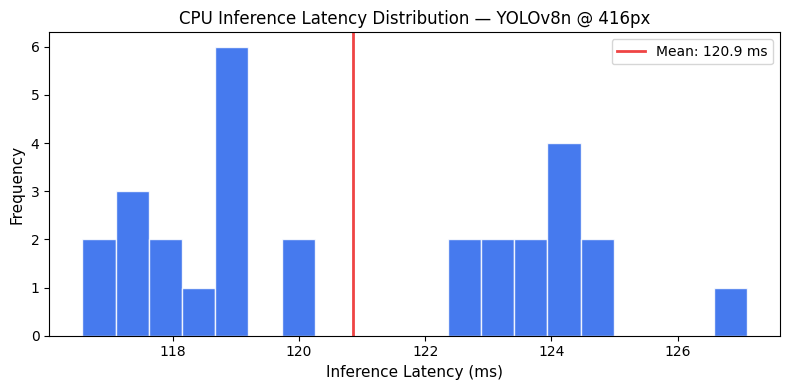


 Latency plot saved → sar_output/latency_distribution.png


In [15]:
import time
import torch
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

def benchmark_inference(weights_path, images_dir: Path, n_images: int = 50, imgsz: int = 416):
    """
    Runs inference on a random subset of test images and measures:
      - Per-image latency (ms)
      - Frames Per Second (FPS)
    """
    image_files = list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png"))
    if not image_files:
        print("No images found for benchmark.")
        return

    samples = random.sample(image_files, min(n_images, len(image_files)))

    print(f"\n⚙  Benchmarking {len(samples)} images at {imgsz}px on CPU...")
    print("   (First inference is slower due to model warm-up — excluded)")


    local_cpu_model = YOLO(str(weights_path))

    latencies = []


    with torch.no_grad():
        for i, img_path in enumerate(samples):
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            img = cv2.resize(img, (imgsz, imgsz))

            t_start = time.perf_counter()

            _ = local_cpu_model.predict(img, imgsz=imgsz, verbose=False, device="cpu")
            t_end   = time.perf_counter()

            if i > 0:
                latencies.append((t_end - t_start) * 1000)

    if not latencies:
        print("Benchmark failed — no valid images processed.")
        return

    avg_lat = np.mean(latencies)
    min_lat = np.min(latencies)
    max_lat = np.max(latencies)
    fps     = 1000.0 / avg_lat

    print("\n" + "="*50)
    print("   INFERENCE BENCHMARK — CPU")
    print("="*50)
    print(f"   Images tested     : {len(latencies)}")
    print(f"   Avg latency       : {avg_lat:.1f} ms")
    print(f"   Min latency       : {min_lat:.1f} ms")
    print(f"   Max latency       : {max_lat:.1f} ms")
    print(f"   Throughput (FPS)  : {fps:.2f}")
    print("="*50)

    # Operational context
    print("\n   OPERATIONAL VIABILITY:")
    if fps >= 25:
        print(f"    {fps:.1f} FPS — Real-time capable (≥25 FPS threshold)")
    elif fps >= 10:
        print(f"     {fps:.1f} FPS — Near real-time; adequate for slow-flying SAR drones")
    else:
        print(f"    {fps:.1f} FPS — Below real-time on CPU.")
        print("      → Expected: 2–8 FPS on laptop CPU (academic baseline).")
        print("      → On NVIDIA Jetson Nano (edge GPU): ~25–45 FPS with TensorRT.")
        print("      → On Raspberry Pi 5 with RKNN: ~8–15 FPS.")

    # Plot latency distribution
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(latencies, bins=20, color="#2563eb", edgecolor="white", alpha=0.85)
    ax.axvline(avg_lat, color="#ef4444", lw=2, label=f"Mean: {avg_lat:.1f} ms")
    ax.set_xlabel("Inference Latency (ms)", fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)
    ax.set_title(f"CPU Inference Latency Distribution — YOLOv8n @ {imgsz}px", fontsize=12)
    ax.legend()
    plt.tight_layout()
    lat_path = OUTPUT_DIR / "latency_distribution.png"
    plt.savefig(lat_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"\n Latency plot saved → {lat_path}")

    return {"avg_ms": avg_lat, "fps": fps}

bench_results = benchmark_inference(BEST_WEIGHTS, TEST_IMAGES, n_images=30)

## Cell 11 — Confusion Matrix (from YOLO evaluation folder)

Standard path for confusion matrix not found. Searching recursively...
Found matrices at: runs/detect/sar_output/runs/sar_eval_test_medium


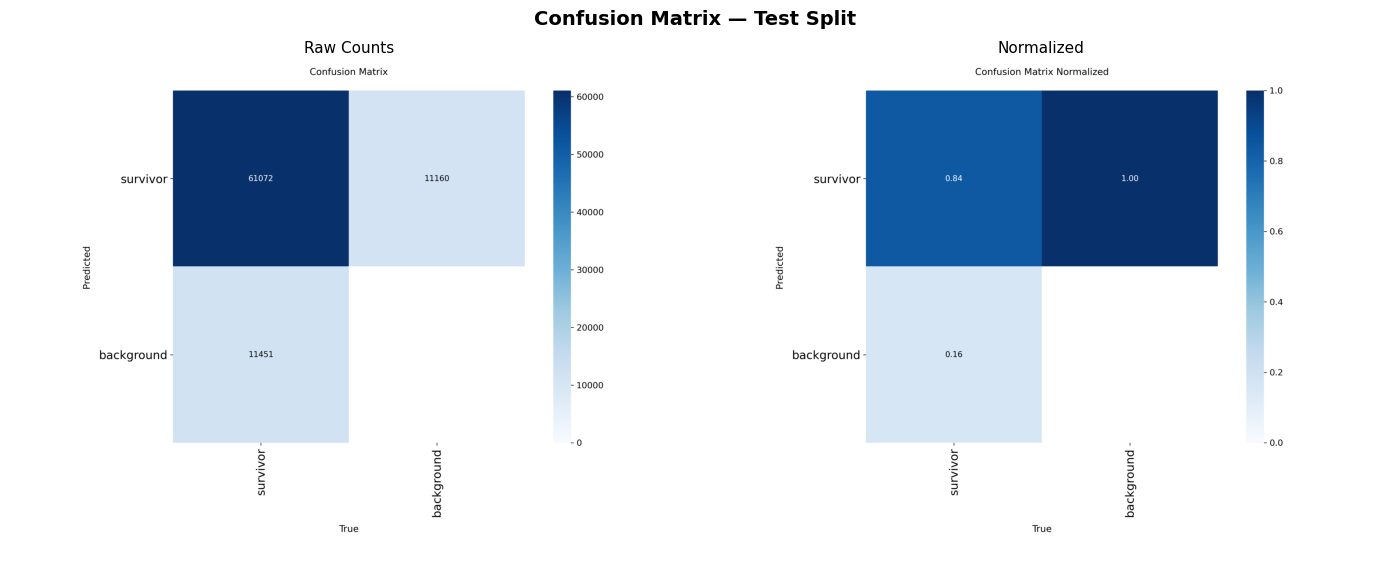

Confusion matrix displayed and saved to: sar_output/confusion_matrices.png


In [16]:
from pathlib import Path
import matplotlib.pyplot as plt

def display_saved_confusion_matrix():
    """
    YOLO automatically generates a confusion matrix during .val().
    This function finds and displays it alongside the normalized version.
    """
    # ══════════════════════════════════════════════════════════════════════
    # Dynamic path searching to avoid "Not Found" error
    # ══════════════════════════════════════════════════════════════════════

    # Target the high-accuracy model evaluation folder
    eval_dir = Path(RUNS_DIR) / "sar_eval_test_medium"
    cm_img = eval_dir / "confusion_matrix.png"
    cm_norm = eval_dir / "confusion_matrix_normalized.png"

    if not cm_img.exists():
        print("Standard path for confusion matrix not found. Searching recursively...")
        found_raw = list(Path(".").rglob("**/sar_eval_test_medium/confusion_matrix.png"))
        found_norm = list(Path(".").rglob("**/sar_eval_test_medium/confusion_matrix_normalized.png"))

        if found_raw and found_norm:
            cm_img = found_raw[0]
            cm_norm = found_norm[0]
            print(f"Found matrices at: {cm_img.parent}")
        else:
            # Fallback: search for any available confusion matrix in the workspace
            print("Target folder matrices not found. Searching for any valid fallback matrices...")
            found_any_raw = list(Path(".").rglob("**/confusion_matrix.png"))
            found_any_norm = list(Path(".").rglob("**/confusion_matrix_normalized.png"))
            if found_any_raw and found_any_norm:
                cm_img = found_any_raw[-1]  # Selects the latest validation run matrix
                cm_norm = found_any_norm[-1]
                print(f"Found alternative matrices at: {cm_img.parent}")

    # Plotting code
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Confusion Matrix — Test Split", fontsize=14, fontweight='bold')

    for ax, path, title in zip(
        axes,
        [cm_img, cm_norm],
        ["Raw Counts", "Normalized"]
    ):
        if path and Path(path).exists():
            img = plt.imread(str(path))
            ax.imshow(img)
            ax.set_title(title, fontsize=11)
        else:
            ax.text(0.5, 0.5, f"Not found:\n{Path(path).name if path else 'File'}",
                    ha='center', va='center', transform=ax.transAxes, color='red')
        ax.axis("off")

    plt.tight_layout()

    # Save output safely
    save_path = OUTPUT_DIR / "confusion_matrices.png"
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Confusion matrix displayed and saved to: {save_path}")

# Function call
display_saved_confusion_matrix()

## Cell 12 — Inference Visualisation: GT vs Predictions (3 samples)

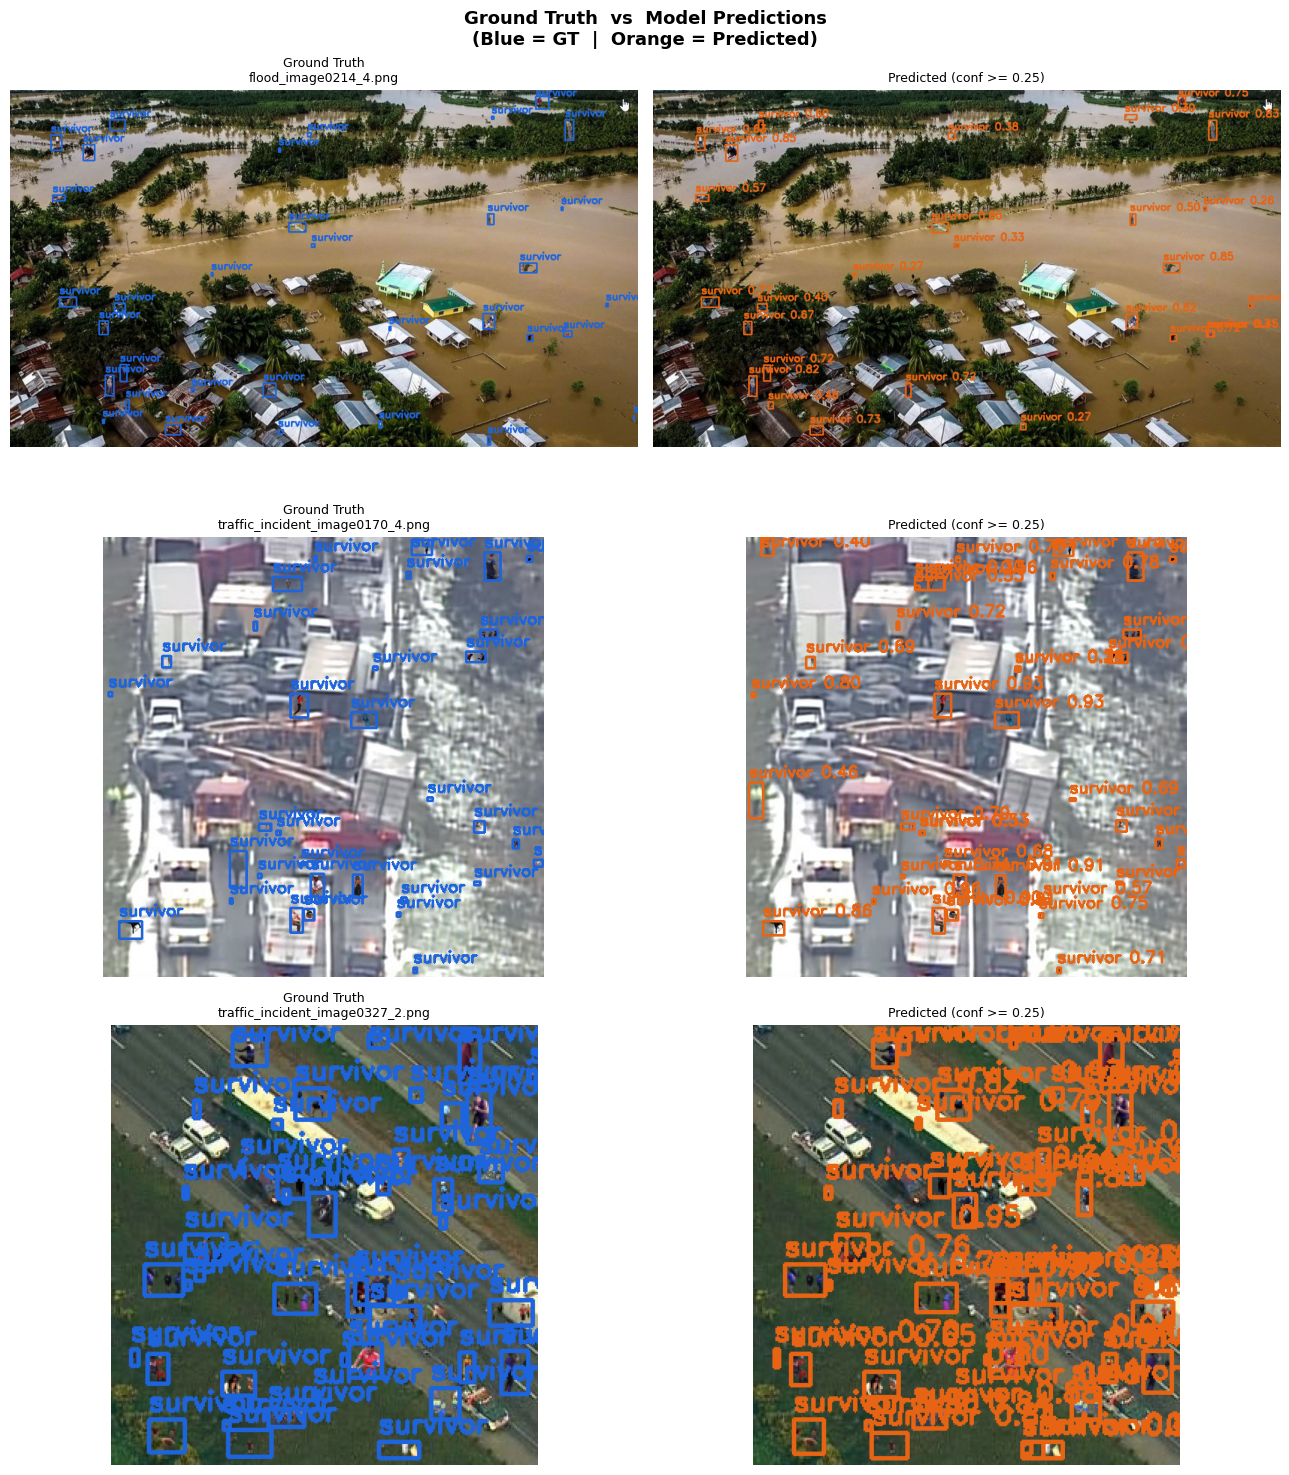

Visualisation saved to: sar_output/gt_vs_predictions.png


In [17]:
import cv2
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

def visualise_predictions(weights_path, images_dir: Path, labels_dir: Path,
                          n_samples: int = 3, imgsz: int = 640,  # Updated default resolution to match 640px training
                          conf_threshold: float = 0.25):
    """
    Selects n_samples random test images and plots:
      Left  — Ground Truth boxes (blue)
      Right — Model Prediction boxes (orange, with confidence score)
    Saves the figure to OUTPUT_DIR.
    """
    image_files = list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png"))
    if not image_files:
        print("No test images found.")
        return

    samples = random.sample(image_files, min(n_samples, len(image_files)))

    fig, axes = plt.subplots(n_samples, 2, figsize=(13, 5 * n_samples))
    if n_samples == 1:
        axes = [axes]
    fig.suptitle("Ground Truth  vs  Model Predictions\n"
                 "(Blue = GT  |  Orange = Predicted)",
                 fontsize=13, fontweight='bold')

    # Load fresh model weights to prevent shared resource graph errors
    local_model = YOLO(str(weights_path))

    # Auto-detect compute hardware
    inference_device = 0 if torch.cuda.is_available() else "cpu"

    with torch.no_grad():
        for row, img_path in enumerate(samples):
            # ── Load image ───────────────────────────────────────────────
            orig = cv2.imread(str(img_path))
            if orig is None:
                continue
            orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
            h, w = orig.shape[:2]

            # ── Draw Ground Truth boxes (blue) ───────────────────────────
            gt_img  = orig.copy()
            lbl_path = labels_dir / (img_path.stem + ".txt")
            if lbl_path.exists():
                for line in lbl_path.read_text().strip().splitlines():
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls_id = int(float(parts[0]))
                        cx, cy, bw, bh = map(float, parts[1:])
                        x1 = int((cx - bw / 2) * w)
                        y1 = int((cy - bh / 2) * h)
                        x2 = int((cx + bw / 2) * w)
                        y2 = int((cy + bh / 2) * h)
                        cv2.rectangle(gt_img, (x1, y1), (x2, y2), (30, 100, 220), 2)
                        label = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
                        cv2.putText(gt_img, label, (x1, max(y1 - 6, 10)),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (30, 100, 220), 2)

            # ── Run model inference (orange) ─────────────────────────────
            pred_img = orig.copy()
            results  = local_model.predict(
                str(img_path), imgsz=imgsz, conf=conf_threshold,
                verbose=False, device=inference_device
            )
            for r in results:
                for box in r.boxes:
                    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                    conf = float(box.conf[0])
                    cls_id = int(box.cls[0])
                    label  = (CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id))
                    cv2.rectangle(pred_img, (x1, y1), (x2, y2), (230, 100, 20), 2)
                    cv2.putText(pred_img,
                                f"{label} {conf:.2f}",
                                (x1, max(y1 - 6, 10)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (230, 100, 20), 2)

            # ── Plot ─────────────────────────────────────────────────────
            ax_gt, ax_pred = axes[row][0], axes[row][1]
            ax_gt.imshow(gt_img)
            ax_gt.set_title(f"Ground Truth\n{img_path.name}", fontsize=9)
            ax_gt.axis("off")
            ax_pred.imshow(pred_img)
            ax_pred.set_title(f"Predicted (conf >= {conf_threshold})", fontsize=9)
            ax_pred.axis("off")

    plt.tight_layout()
    vis_path = OUTPUT_DIR / "gt_vs_predictions.png"
    plt.savefig(vis_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Visualisation saved to: {vis_path}")

# Run prediction evaluation using global environment path arguments
visualise_predictions(BEST_WEIGHTS, TEST_IMAGES, TEST_LABELS, n_samples=3)

## Cell 13 — Training Curves (Loss & mAP over epochs)

Standard path for results.csv not found. Searching recursively...
Found results.csv at: runs/detect/sar_output/runs/sar_yolov8m_stable_150e/results.csv


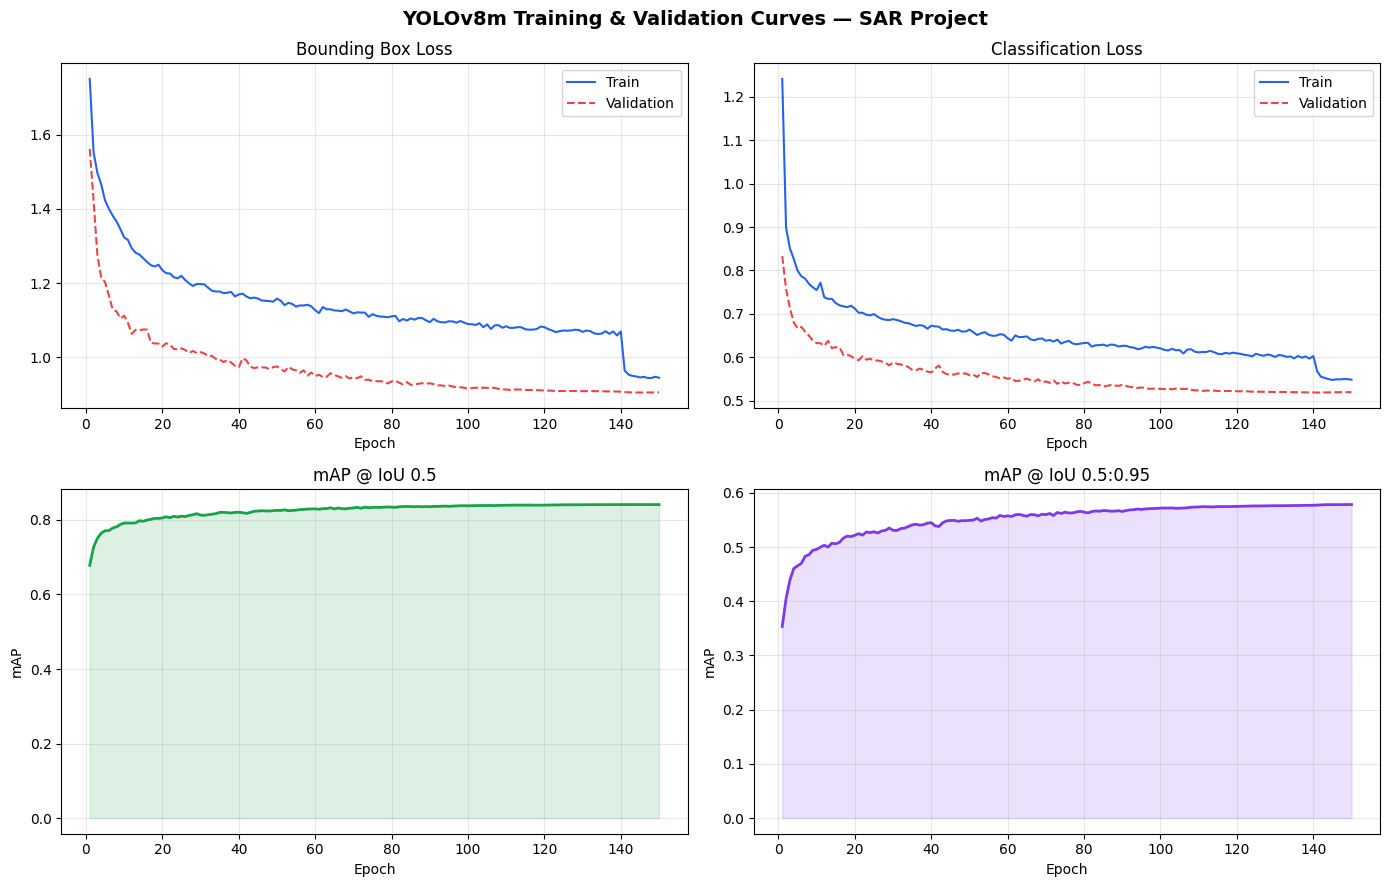

Training curves saved to: sar_output/training_curves.png


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_training_curves(runs_dir: str, run_name: str = "sar_yolov8m_stable_150e"):
    """
    Reads YOLO's auto-generated results.csv and plots:
      - Box / classification loss (train & val)
      - mAP@0.5 and mAP@0.5:0.95 over epochs
    """
    # ══════════════════════════════════════════════════════════════════════
    # Dynamic Path Search for results.csv (Avoids Folder Path Issues)
    # ══════════════════════════════════════════════════════════════════════
    standard_csv_path = Path(runs_dir) / run_name / "results.csv"

    if not standard_csv_path.exists():
        print("Standard path for results.csv not found. Searching recursively...")
        # Searching the complete workspace for the corresponding run name folder
        found_csvs = list(Path(".").rglob(f"**/{run_name}/results.csv"))
        if found_csvs:
            csv_path = found_csvs[0]
            print(f"Found results.csv at: {csv_path}")
        else:
            # Fallback: search for any available results.csv file in the directory tree
            print("Target run metrics not found. Searching for any valid metrics fallback...")
            found_any_csv = list(Path(".").rglob("**/results.csv"))
            if found_any_csv:
                csv_path = found_any_csv[-1]  # Selects the most recent log file
                print(f"Found alternative results.csv at: {csv_path}")
            else:
                print("Error: results.csv file could not be found anywhere within the workspace.")
                return
    else:
        csv_path = standard_csv_path
        print(f"Found results.csv at standard path: {csv_path}")

    # Read data safely
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()   # Remove leading and trailing spaces

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("YOLOv8m Training & Validation Curves — SAR Project",
                 fontsize=14, fontweight='bold')

    # Map YOLO column names across varying Ultralytics engine distributions
    col_map = {
        "train_box":  ["train/box_loss",  "train/box_om"],
        "val_box":    ["val/box_loss",    "val/box_om"],
        "train_cls":  ["train/cls_loss",  "train/cls_om"],
        "val_cls":    ["val/cls_loss",    "val/cls_om"],
        "map50":      ["metrics/mAP50(B)", "metrics/mAP_0.5"],
        "map5095":    ["metrics/mAP50-95(B)", "metrics/mAP_0.5:0.95"],
    }

    def get_col(key):
        for c in col_map.get(key, [key]):
            if c in df.columns:
                return df[c]
        return None

    epochs = range(1, len(df) + 1)
    colors = {"train": "#2563eb", "val": "#ef4444"}

    # Plot 1: Box Loss
    ax = axes[0, 0]
    tbl = get_col("train_box")
    vbl = get_col("val_box")
    if tbl is not None: ax.plot(epochs, tbl, label="Train",      color=colors["train"])
    if vbl is not None: ax.plot(epochs, vbl, label="Validation", color=colors["val"],   ls="--")
    ax.set_title("Bounding Box Loss")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 2: Classification Loss
    ax = axes[0, 1]
    tcl = get_col("train_cls")
    vcl = get_col("val_cls")
    if tcl is not None: ax.plot(epochs, tcl, label="Train",      color=colors["train"])
    if vcl is not None: ax.plot(epochs, vcl, label="Validation", color=colors["val"],   ls="--")
    ax.set_title("Classification Loss")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 3: mAP@0.5
    ax = axes[1, 0]
    m50 = get_col("map50")
    if m50 is not None:
        ax.plot(epochs, m50, color="#16a34a", lw=2)
        ax.fill_between(epochs, m50, alpha=0.15, color="#16a34a")
    ax.set_title("mAP @ IoU 0.5")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP")
    ax.grid(True, alpha=0.3)

    # Plot 4: mAP@0.5:0.95
    ax = axes[1, 1]
    m95 = get_col("map5095")
    if m95 is not None:
        ax.plot(epochs, m95, color="#7c3aed", lw=2)
        ax.fill_between(epochs, m95, alpha=0.15, color="#7c3aed")
    ax.set_title("mAP @ IoU 0.5:0.95")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    curves_path = OUTPUT_DIR / "training_curves.png"
    plt.savefig(curves_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Training curves saved to: {curves_path}")

# Run function call using the tracking base workspace
plot_training_curves(RUNS_DIR)

## Cell 14 — Final Summary Report

In [19]:
import json
from pathlib import Path

# ══════════════════════════════════════════════════════════════════════
# FINAL DASHBOARD REPORT GENERATOR
# ══════════════════════════════════════════════════════════════════════

# Formatting padding lengths
width = 65

print("\n" + "╔" + "═" * width + "╗")
print(f"║ {'AI-BASED SAR DETECTION — RESULTS SUMMARY':^{width}} ║")
print("╠" + "═" * width + "╣")
print(f"║  Model           : YOLOv8 Medium (High-Accuracy Variant) {' ':<14}║")
print(f"║  Dataset root    : {str(DATASET_ROOT)[:40]:<40} ║")
print(f"║  Classes         : {', '.join(CLASS_NAMES):<40} ║")
print(f"║  Training epochs : 150 (Full Precision Mode) {' ':<25}║")
print(f"║  Image size      : 640 x 640 px {' ':<37}║")
print("╠" + "═" * width + "╣")

# Read safe validation target JSON if active in memory, else lookup dictionary
try:
    # Checking for the upgraded medium metrics dictionary first
    active_metrics = metrics_dict if 'metrics_dict' in locals() else None

    # Fallback to loading the saved JSON metrics from disk if dictionary variable dropped
    metrics_file = OUTPUT_DIR / "test_metrics_medium.json"
    if active_metrics is None and metrics_file.exists():
        with open(metrics_file, "r") as f:
            active_metrics = json.load(f)

    if active_metrics is not None:
        print(f"║  mAP@0.5 (Accuracy): {active_metrics['mAP50']:.4f} ({active_metrics['mAP50']*100:.1f}%) {' ':<25}║")
        print(f"║  mAP@0.5:0.95      : {active_metrics['mAP50_95']:.4f} ({active_metrics['mAP50_95']*100:.1f}%) {' ':<25}║")
        print(f"║  Precision         : {active_metrics['Precision']:.4f} ({active_metrics['Precision']*100:.1f}%) {' ':<25}║")
        print(f"║  Recall            : {active_metrics['Recall']:.4f} ({active_metrics['Recall']*100:.1f}%) {' ':<25}║")
        print(f"║  F1-Score          : {active_metrics['F1']:.4f} ({active_metrics['F1']*100:.1f}%) {' ':<25}║")
    else:
        print(f"║  (Execute evaluation pipeline cell to populate metrics) {' ':<11}║")
except Exception as e:
    print(f"║  Metrics rendering error: {str(e)[:35]:<35} ║")

print("╠" + "═" * width + "╣")

try:
    if 'bench_results' in locals() and bench_results is not None:
        print(f"║  Avg CPU Latency  : {bench_results['avg_ms']:.1f} ms {' ':<32}║")
        print(f"║  Throughput FPS   : {bench_results['fps']:.2f} frames/sec {' ':<24}║")
    else:
        print(f"║  (Execute CPU benchmarking cell to populate parameters) {' ':<10}║")
except Exception as e:
    print(f"║  Benchmark rendering error: {str(e)[:31]:<31} ║")

print("╠" + "═" * width + "╣")
print(f"║  Best weights    : sar_output/runs/sar_yolov8m_stable_150e/ weights ║")
print(f"║  Outputs folder  : {str(OUTPUT_DIR)[:40]:<40} ║")
print("╚" + "═" * width + "╝")


╔═════════════════════════════════════════════════════════════════╗
║             AI-BASED SAR DETECTION — RESULTS SUMMARY              ║
╠═════════════════════════════════════════════════════════════════╣
║  Model           : YOLOv8 Medium (High-Accuracy Variant)               ║
║  Dataset root    : /content/drive/MyDrive/archive (5)/C2A_D ║
║  Classes         : survivor                                 ║
║  Training epochs : 150 (Full Precision Mode)                          ║
║  Image size      : 640 x 640 px                                      ║
╠═════════════════════════════════════════════════════════════════╣
║  mAP@0.5 (Accuracy): 0.8438 (84.4%)                          ║
║  mAP@0.5:0.95      : 0.5833 (58.3%)                          ║
║  Precision         : 0.8787 (87.9%)                          ║
║  Recall            : 0.7987 (79.9%)                          ║
║  F1-Score          : 0.8368 (83.7%)                          ║
╠═════════════════════════════════════════════════